In [3]:
import matplotlib.pyplot as plt
%ls log
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


ls: cannot access 'log': No such file or directory


In [4]:
import json
import glob
import pandas as pd 
df = pd.read_csv("/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/sparse/mult/tests/log.csv")
df

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep
0,SparseUT,500x500,50,0.021087,21.146624,0
1,Dense,500x500,50,0.015583,15.564800,0
2,SparseTorch,500x500,50,0.032552,32.571392,0
3,SparseUT,500x500,70,0.002594,2.620416,0
4,Dense,500x500,70,0.002690,2.677760,0
...,...,...,...,...,...,...
115,Dense,10000x10000,98,0.095955,95.924225,0
116,SparseTorch,10000x10000,98,0.474779,476.522491,0
117,SparseUT,10000x10000,99,0.002519,4.649984,0
118,Dense,10000x10000,99,0.095936,95.915009,0


Dense [26, 25, 25, 25, 25, 25, 25, 25, 25, 25]
SparseTorch [3088, 1805, 1244, 892, 607, 312, 241, 186, 123, 57]
SparseUT [53, 34, 22, 17, 12, 6, 5, 4, 3, 2]


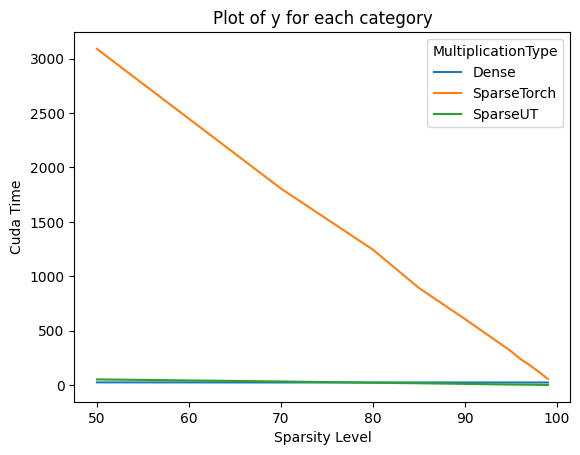

In [20]:
df_dlvl = df[df.dense_level == "5000x5000"]


# Group by the 'category' column and plot each group
for category, group in df_dlvl.groupby('isSparse'):
    plt.plot(group['sparsity_level'], group['cuda_elapsed_time'], label=category)
    print(category, list(map(int, group['cuda_elapsed_time'])))
    

# Add title and labels
plt.title('Plot of y for each category')
plt.xlabel('Sparsity Level')
plt.ylabel('Cuda Time')

# Show legend
plt.legend(title='MultiplicationType')

# Display the plot
plt.show()


Dense [26, 25, 25, 25, 25, 25, 25, 25, 25, 25]
SparseUT [53, 34, 22, 17, 12, 6, 5, 4, 3, 2]


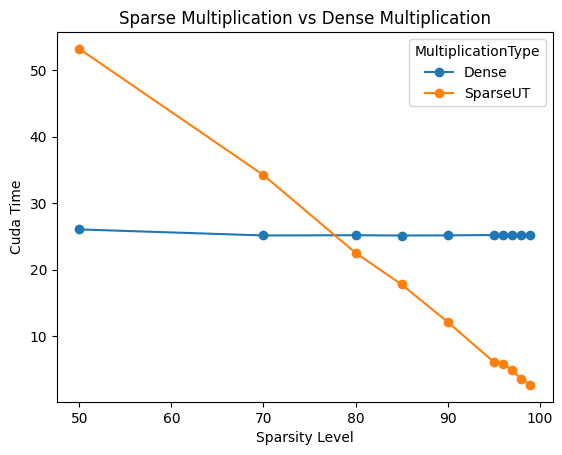

In [24]:

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
for category, group in df_dlvl.groupby('isSparse'):
    plt.plot(group['sparsity_level'], group['cuda_elapsed_time'],marker='o', linestyle='-', label=category)
    print(category, list(map(int, group['cuda_elapsed_time'])))
    

# Add title and labels
plt.title('Sparse Multiplication vs Dense Multiplication')
plt.xlabel('Sparsity Level')
plt.ylabel('Cuda Time')

# Show legend
plt.legend(title='MultiplicationType')

# Display the plot
plt.show()

In [ ]:
df.drop(["name","time_elapsed_cpu_1core"], axis=1).plot(x='sparsity')